# Support visualisation

## Configuration du notebook

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, clear_output
import ipywidgets as widgets

In [125]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from skorch import NeuralNetClassifier

## Algorithme du Perceptron

In [2]:
BLUE = "#3498DB"
RED = "#E74C3C"
GREEN = "#2ECC71"

In [3]:
def plot_line(w, points=None, points_pos=None, points_neg=None, dist=False):
    a, b, c = w
    if np.abs(b) <= 1e-8:
        b = 1e-8
    x1 = np.linspace(-3., 3., 100)
    x2 = (- a * x1 - c) / b
    plt.plot(x1, x2, color="k", label=r"$\mathcal{D}$")
    if points is not None:
        plt.scatter(points[:,0], points[:,1], marker="o", color=GREEN, zorder=10, edgecolor="w", label=r"$\mathcal{P}$")
    if points_pos is not None:
        plt.scatter(points_pos[:,0], points_pos[:,1], marker="o", color=RED, zorder=10, edgecolor="w", label=r"$\mathcal{P} \text{  avec  } Y = 1$")
    if points_neg is not None:
        plt.scatter(points_neg[:,0], points_neg[:,1], marker="o", color=BLUE, zorder=10, edgecolor="w", label=r"$\mathcal{P} \text{  avec  } Y = 0$")
    if dist:
        X1, X2 = np.meshgrid(np.linspace(x1.min(), x1.max(), 50), np.linspace(x2.min(), x2.max(), 50))
        Z = a * X1 + b * X2 + c
        ctf = plt.contourf(X1, X2, Z, cmap="bwr", levels=32)
        plt.colorbar(ctf, orientation="horizontal", location="top");
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")
    plt.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))
    plt.xlim(-3., 3.)
    plt.ylim(-3., 3.)

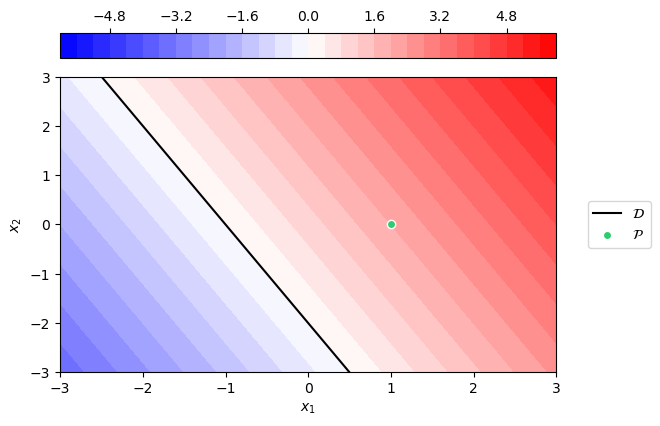

In [4]:
w = np.array([1.0, 0.5, 1.0])
points = np.array([[1., 0.]])
plot_line(w, points=points, dist=True)

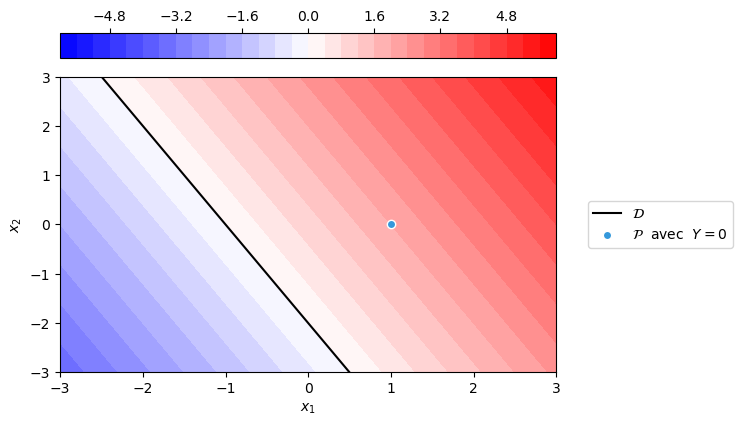

In [5]:
w = np.array([1.0, 0.5, 1.0])
points = np.array([[1., 0.]])
plot_line(w, points_neg=points, dist=True)

In [391]:
# --- Configuration des données ---
X = np.array([[0, 0, 1], [0, 1, 1], [1, 0, 1], [1, 1, 1]])
y_and = np.array([0, 0, 0, 1])
y_or  = np.array([0, 1, 1, 1])

state = {
    'w': np.array([-0.2,  0.4, -0.1]),
    'y': y_and
}

# --- Composants Graphiques ---
out = widgets.Output(layout={'height': '450px', 'max_height': '450px', 'overflow': 'hidden'})

def get_prediction(w, x):
    return 1 if np.dot(w, x) >= 0 else 0

def update_plot():
    # C'est ici qu'on empêche le scroll : on nettoie l'output AVANT de dessiner
    with out:
        w = state['w']
        y_true = state['y']
        
        # On crée la figure mais on ne l'affiche pas encore
        fig, ax = plt.subplots(figsize=(6, 5))
        
        # 1. Calcul dynamique du fond Z basé sur les NOUVEAUX poids w
        nx, ny = 100, 100
        x_grid = np.linspace(-0.5, 1.5, nx)
        y_grid = np.linspace(-0.5, 1.5, ny)
        X1, X2 = np.meshgrid(x_grid, y_grid)
        
        # FORMULE CRUCIALE : Z dépend de w
        Z = w[0]*X1 + w[1]*X2 + w[2] 
        
        # 2. Affichage du fond (Contourf)
        v_limit = max(abs(Z.min()), abs(Z.max()), 0.1)
        cf = ax.contourf(X1, X2, Z, levels=50, cmap='bwr', alpha=0.5, vmin=-v_limit, vmax=+v_limit)
        
        # 3. La droite D (z=0)
        if np.abs(w[1]) > 1e-5:
            ax.plot(x_grid, (-w[0]*x_grid - w[2])/w[1], color='black', lw=2, label=r'$\mathcal{D} (z=0)$')
        
        # 4. Points (Rouge=1, Bleu=0)
        colors = ['blue' if val == 0 else 'red' for val in y_true]
        ax.scatter(X[:, 0], X[:, 1], c=colors, s=100, edgecolors='white', linewidth=1.5, zorder=5)
        
        # Vérification convergence
        errors = sum(1 for i in range(len(y_true)) if get_prediction(w, X[i]) != y_true[i])
        
        ax.set_title(f"Perceptron - Erreurs : {errors}")
        ax.set_xlim(-0.2, 1.2)
        ax.set_ylim(-0.2, 1.2)
        ax.legend(loc='upper left')
        
        # On vide l'output et on affiche la figure propre
        clear_output(wait=True)
        plt.show()
        plt.close(fig) # Important pour ne pas accumuler les figures en mémoire

# --- Callbacks ---
def on_epoch_clicked(b):
    w = state['w']
    y_true = state['y']
    alpha = slider_alpha.value
    for i in range(len(y_true)):
        y_pred = get_prediction(w, X[i])
        w = w + alpha * (y_true[i] - y_pred) * X[i]
    state['w'] = w
    update_plot()

def on_reset_clicked(b):
    state['w'] = np.array([-0.2,  0.4, -0.1])
    update_plot()

def on_logic_change(change):
    state['y'] = y_or if change['new'] else y_and
    on_reset_clicked(None)

# --- Interface ---
btn_epoch = widgets.Button(description="Époque suivante", button_style='primary')
btn_reset = widgets.Button(description="Ré-initialisation", button_style='warning')
slider_alpha = widgets.FloatSlider(value=0.1, min=0.001, max=10.0, step=0.001, description=r'$\alpha$', readout_format='.3f')
check_logic = widgets.Checkbox(value=False, description='Table OU')

btn_epoch.on_click(on_epoch_clicked)
btn_reset.on_click(on_reset_clicked)
check_logic.observe(on_logic_change, names='value')

layout = widgets.VBox([
    widgets.HBox([btn_epoch, btn_reset, check_logic]),
    slider_alpha,
    out
])

display(layout)
update_plot()

In [388]:
def rugby():
    # Données des joueurs de rugby
    X1 = np.array([175., 180., 193., 185., 186., 185., 177., 182., 181., 184., 184., 203., 200., 205., 197., 203., 203., 195., 199., 
                   190., 191., 194., 190., 192., 174., 169., 182., 177., 175., 184., 186., 185., 190., 190., 184., 194., 192., 188., 
                   183., 188., 184., 185., 182., 178.]).reshape(-1, 1)  # taille 
    X2 = np.array([115., 119., 142., 112., 133., 124., 125., 107., 110., 109., 112., 142., 105., 133., 122., 138., 116., 108., 114., 
                   111., 114., 108., 90., 107., 86., 82., 83., 83., 75., 86., 94., 89., 98., 100., 97., 94., 108., 102., 95., 97., 
                   84., 84., 84., 87.]).reshape(-1, 1)  # poids
    X1 = (X1 - X1.mean()) / X1.std()
    X2 = (X2 - X2.mean()) / X2.std()
    Y = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 
                  0, 0, 0, 0, 0, 0]).reshape(-1, 1)  # 1 avant, 0 trois-quart
    return X1, X2, np.hstack((X1, X2, np.ones_like(X1))), Y

In [389]:
X.max(axis=0)

array([1, 1, 1])

In [392]:
# --- Configuration des données ---
_, _, X, Y = rugby()

state = {
    'w': np.array([1. ,  -1., 0. ]),
    'y': Y,
    'observation': -1,
}

# --- Composants Graphiques ---
out = widgets.Output(layout={'height': '500px', 'max_height': '500px', 'overflow': 'hidden'})

def get_prediction(w, x):
    return 1 if np.dot(w, x) >= 0 else 0

def update_plot():
    # C'est ici qu'on empêche le scroll : on nettoie l'output AVANT de dessiner
    with out:
        w = state['w']
        y_true = state['y']
        i = state['observation']
        
        # On crée la figure mais on ne l'affiche pas encore
        fig, ax = plt.subplots(figsize=(6, 5))
        
        # 1. Calcul dynamique du fond Z basé sur les NOUVEAUX poids w
        nx, ny = 100, 100
        x_grid = np.linspace(-2.5, 2.5, nx)
        y_grid = np.linspace(-2.5, 2.5, ny)
        X1, X2 = np.meshgrid(x_grid, y_grid)
        
        # FORMULE CRUCIALE : Z dépend de w
        Z = w[0]*X1 + w[1]*X2 + w[2] 
        
        # 2. Affichage du fond (Contourf)
        v_limit = max(abs(Z.min()), abs(Z.max()), 0.1)
        cf = ax.contourf(X1, X2, Z, levels=50, cmap='bwr', alpha=0.5, vmin=-v_limit, vmax=+v_limit)
        
        # 3. La droite D (z=0)
        if np.abs(w[1]) < 1e-8:
            b = 1e-8
        else:
            b = w[1]
        ax.plot(x_grid, (-w[0]*x_grid - w[2])/b, color='black', lw=2, label=r'$\mathcal{D} (z=0)$')
        
        # 4. Points (Rouge=1, Bleu=0)
        colors = ['blue' if val == 0 else 'red' for val in y_true]
        ax.scatter(X[:, 0], X[:, 1], c=colors, s=100, edgecolors='white', linewidth=1.5, zorder=5)
        if i > 0:
            ax.scatter([X[i, 0]], [X[i, 1]], s=300, marker='o', color="lime", linewidth=1, zorder=4)
        
        # Vérification convergence
        errors = sum(1 for i in range(len(y_true)) if get_prediction(w, X[i]) != y_true[i])
        
        ax.set_title(f"Perceptron - Erreurs : {errors}")
        ax.set_xlim(-2.5, 2.5)
        ax.set_ylim(-2.5, 2.5)
        ax.set_xlabel("Taille [cm]")
        ax.set_ylabel("Poids [kg]")
        ax.legend(loc='upper left')
        
        # On vide l'output et on affiche la figure propre
        clear_output(wait=True)
        plt.show()
        plt.close(fig) # Important pour ne pas accumuler les figures en mémoire

# --- Callbacks ---
def on_iteration_clicked(b):
    w = state['w']
    y_true = state['y']
    i = state['observation']
    if (i + 1) < y_true.shape[0]:
        i += 1
    else:
        i = 0
    alpha = slider_alpha.value
    y_pred = get_prediction(w, X[i])
    w = w + alpha * (y_true[i] - y_pred) * X[i]
    state['w'] = w
    state['observation'] = i
    update_plot()

def on_epoch_clicked(b):
    w = state['w']
    y_true = state['y']
    i = state['observation']
    alpha = slider_alpha.value
    for i in range(i+1, len(y_true)):
        y_pred = get_prediction(w, X[i])
        w = w + alpha * (y_true[i] - y_pred) * X[i]
    state['w'] = w
    state['observation'] = -1
    update_plot()
    
def on_reset_clicked(b):
    state['w'] = np.array([-1. ,  -1., 0. ])
    state['observation'] = 0
    update_plot()

# --- Interface ---
btn_interation = widgets.Button(description="Itération suivante", button_style='primary')
btn_epoch = widgets.Button(description="Epoch suivante", button_style='primary')
btn_reset = widgets.Button(description="Ré-initialisation", button_style='warning')
slider_alpha = widgets.FloatLogSlider(value=0.0001, base=10, min=-4, max=2, step=0.1, description=r'$\alpha$', readout_format='.4f')

btn_interation.on_click(on_iteration_clicked)
btn_epoch.on_click(on_epoch_clicked)
btn_reset.on_click(on_reset_clicked)

layout = widgets.VBox([
    widgets.HBox([btn_interation, btn_epoch, btn_reset]),
    slider_alpha,
    out
])

display(layout)
update_plot()

## Fonction logistique

In [108]:
def heaviside(z):
    return np.where(z >= 0, 1., 0.)

def logistic(z):
    return 1 / (1 + np.exp(-z))

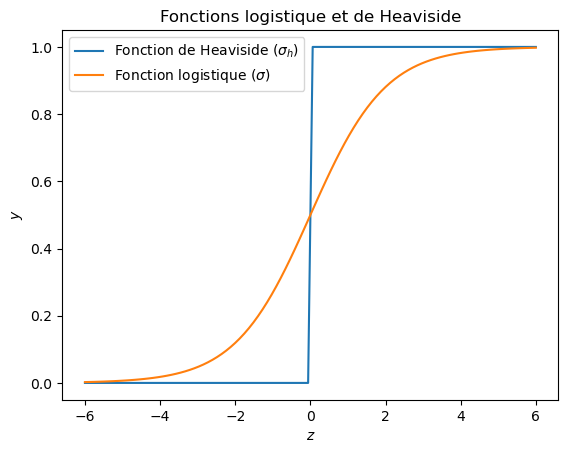

In [113]:
z = np.linspace(-6., 6., 100)
plt.plot(z, heaviside(z), label=r"Fonction de Heaviside ($\sigma_h$)")
plt.plot(z, logistic(z), label=r"Fonction logistique ($\sigma$)")
plt.xlabel(r"$z$")
plt.ylabel(r"$y$")
plt.title("Fonctions logistique et de Heaviside")
plt.legend();

## Fonctions d'activation

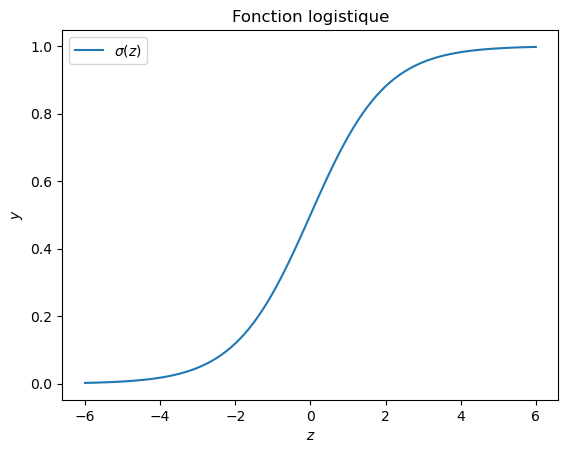

In [118]:
z = np.linspace(-6., 6., 100)
plt.plot(z, logistic(z), label=r"$\sigma(z)$")
plt.xlabel(r"$z$")
plt.ylabel(r"$y$")
plt.title("Fonction logistique")
plt.legend();

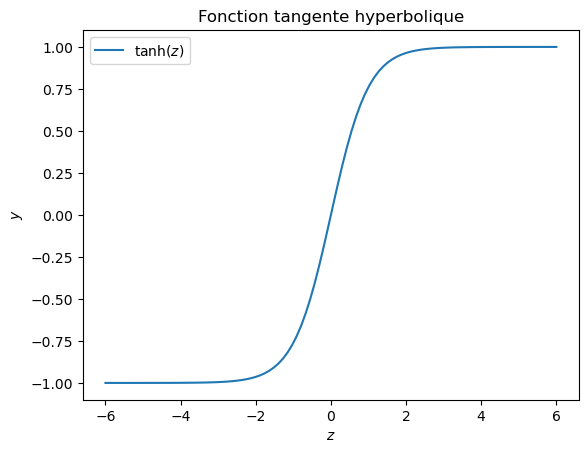

In [120]:
z = np.linspace(-6., 6., 100)
plt.plot(z, np.tanh(z), label=r"$\tanh(z)$")
plt.xlabel(r"$z$")
plt.ylabel(r"$y$")
plt.title("Fonction tangente hyperbolique")
plt.legend();

In [121]:
def relu(z):
    return np.where(z >= 0, z, 0)

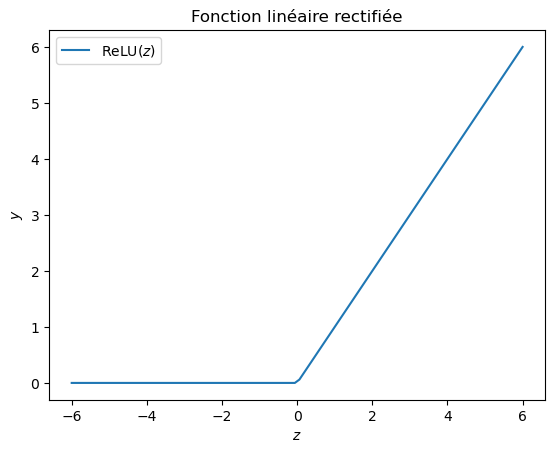

In [123]:
z = np.linspace(-6., 6., 100)
plt.plot(z, relu(z), label=r"$\operatorname{ReLU}(z)$")
plt.xlabel(r"$z$")
plt.ylabel(r"$y$")
plt.title("Fonction linéaire rectifiée")
plt.legend();

## Porte XOR

In [275]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 2),
            nn.Sigmoid(),
            nn.Linear(2, 1),
            nn.Sigmoid()
        )

    def forward(self, X):
        return self.model.forward(X)

In [294]:
net = NeuralNetClassifier(
    Model,
    max_epochs=1000,
    lr=0.1,
    optimizer=torch.optim.Adam,
    criterion=nn.BCELoss,
    iterator_train__batch_size=None,
    device='cpu',
    train_split=None
)

In [295]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]).astype(np.float32)
Y = np.array([0, 1, 1, 0]).reshape(-1, 1).astype(np.float32)

In [329]:
# net.fit(X, Y)
# net.save_params(f_params='./modèles/porte_XOR_model.pkl', f_optimizer='./modèles/porte_XOR_opt.pkl', f_history='./modèles/porte_XOR_history.json')

In [330]:
net.initialize()
net.load_params(f_params='./modèles/porte_XOR_model.pkl', f_optimizer='./modèles/porte_XOR_opt.pkl', f_history='./modèles/porte_XOR_history.json')

Re-initializing module.
Re-initializing criterion.
Re-initializing optimizer.


In [331]:
net.module_

Model(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=2, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=2, out_features=1, bias=True)
    (3): Sigmoid()
  )
)

In [332]:
s = 500
X1, X2 = np.meshgrid(np.linspace(-0.2, 1.2, s), np.linspace(-0.2, 1.2, s))
Xi = np.stack((X1.ravel(), X2.ravel())).T.astype(np.float32)

In [333]:
Xi

array([[-0.2       , -0.2       ],
       [-0.19719438, -0.2       ],
       [-0.19438878, -0.2       ],
       ...,
       [ 1.1943887 ,  1.2       ],
       [ 1.1971943 ,  1.2       ],
       [ 1.2       ,  1.2       ]], shape=(250000, 2), dtype=float32)

In [334]:
Yi = net.predict(Xi)
Ci = np.where(Yi >= 0.5, 1.0, 0.0).reshape(s, s)

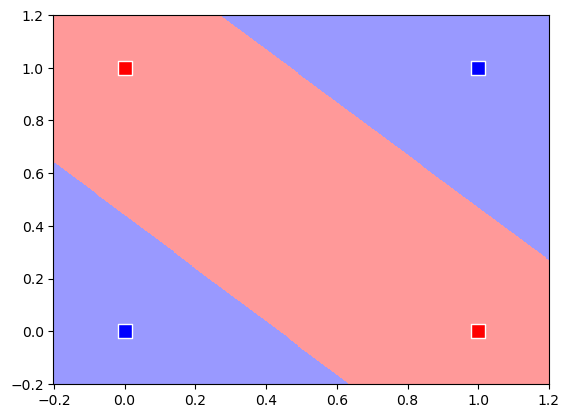

In [335]:
plt.pcolormesh(X1, X2, Ci, cmap="bwr", alpha=0.4, vmin=0., vmax=1.)
plt.scatter(X[:,0], X[:,1], c=Y, marker="s", cmap='bwr', edgecolor="w", s=100);

In [369]:
first_layer = net.module_.model[0:2]
first_layer

Sequential(
  (0): Linear(in_features=2, out_features=2, bias=True)
  (1): Sigmoid()
)

In [370]:
last_layer = net.module_.model[2:4]
last_layer

Sequential(
  (2): Linear(in_features=2, out_features=1, bias=True)
  (3): Sigmoid()
)

In [371]:
with torch.no_grad():
    Xh = first_layer(torch.as_tensor(X)).numpy()

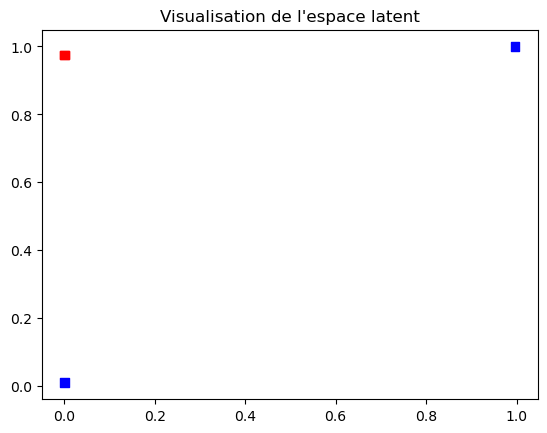

In [372]:
plt.scatter(Xh[:,0], Xh[:, 1], c=Y, cmap='bwr', marker="s");
plt.title("Visualisation de l'espace latent");

In [373]:
Xh

array([[9.9734586e-01, 9.9999297e-01],
       [5.5032986e-04, 9.7509289e-01],
       [4.7917137e-04, 9.7496879e-01],
       [7.0250383e-10, 1.0609449e-02]], dtype=float32)

In [374]:
X

array([[0., 0.],
       [0., 1.],
       [1., 0.],
       [1., 1.]], dtype=float32)

In [375]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]).astype(np.float32)
Y_nor =  np.array([1, 0, 0, 0]).reshape(-1, 1).astype(np.float32)
Y_nand = np.array([1, 1, 1, 0]).reshape(-1, 1).astype(np.float32)
Y_andn = np.array([0, 0, 1, 0]).reshape(-1, 1).astype(np.float32)

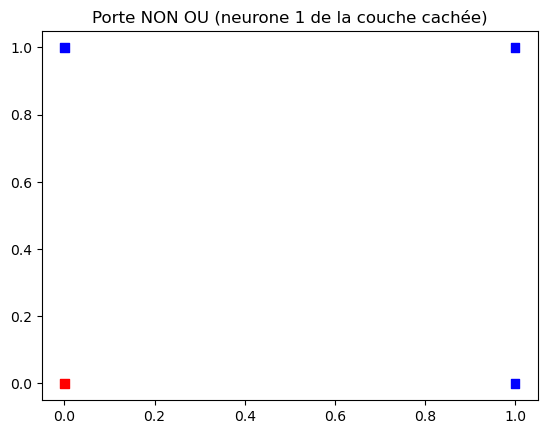

In [376]:
plt.scatter(X[:,0], X[:, 1], c=Y_nor, cmap='bwr', marker="s");
plt.title("Porte NON OU (neurone 1 de la couche cachée)");

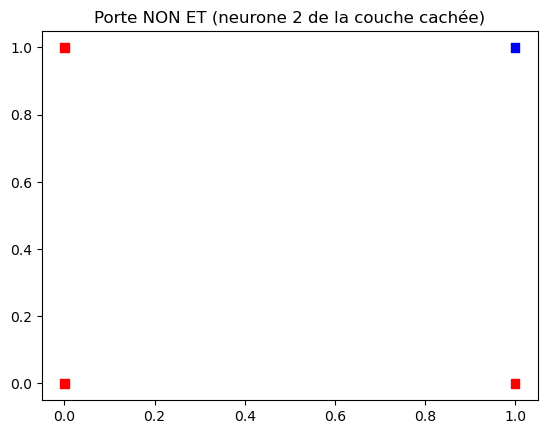

In [377]:
plt.scatter(X[:,0], X[:, 1], c=Y_nand, cmap='bwr', marker="s");
plt.title("Porte NON ET (neurone 2 de la couche cachée)");

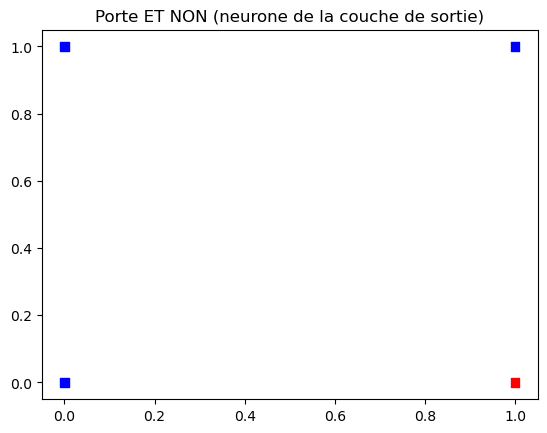

In [378]:
plt.scatter(X[:,0], X[:, 1], c=Y_andn, cmap='bwr', marker="s");
plt.title("Porte ET NON (neurone de la couche de sortie)");

In [379]:
s = 500
X1, X2 = np.meshgrid(np.linspace(-0.2, 1.2, s), np.linspace(-0.2, 1.2, s))
Xi = np.stack((X1.ravel(), X2.ravel())).T.astype(np.float32)

In [380]:
with torch.no_grad():
    Xl = first_layer(torch.as_tensor(Xi)).numpy()

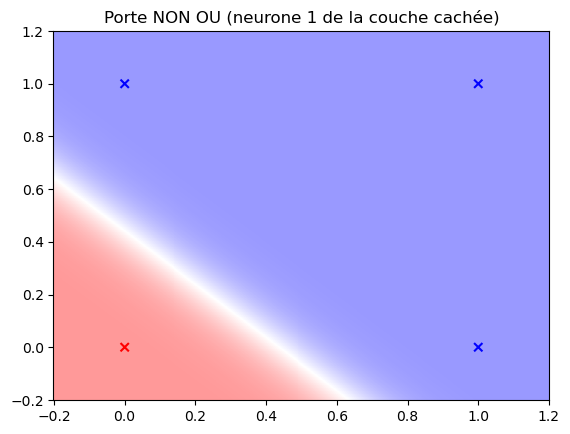

In [381]:
plt.pcolormesh(X1, X2, Xl[:,0].reshape((s, s)), cmap="bwr", alpha=0.4, vmin=0., vmax=1.);
plt.scatter(X[:,0], X[:, 1], c=Y_nor, cmap='bwr', marker="x");
plt.title("Porte NON OU (neurone 1 de la couche cachée)");

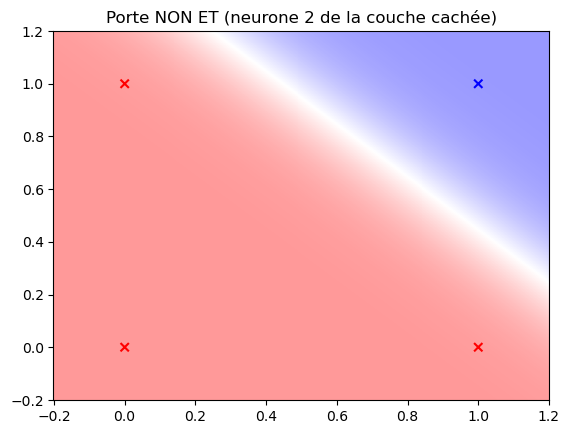

In [382]:
plt.pcolormesh(X1, X2, Xl[:,1].reshape((s, s)), cmap="bwr", alpha=0.4, vmin=0., vmax=1.);
plt.scatter(X[:,0], X[:, 1], c=Y_nand, cmap='bwr', marker="x");
plt.title("Porte NON ET (neurone 2 de la couche cachée)");

In [384]:
with torch.no_grad():
    Xl = last_layer(torch.as_tensor(Xi)).numpy()

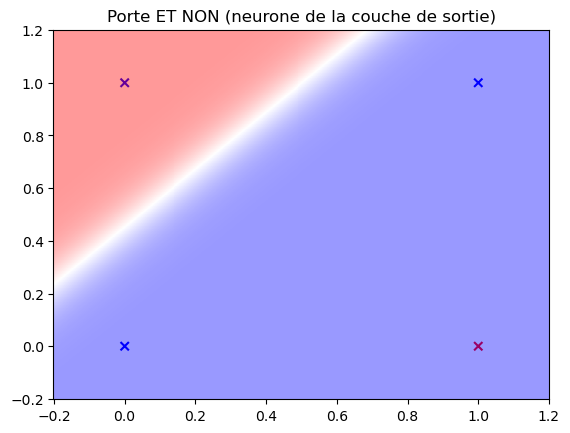

In [386]:
plt.scatter(X[:,0], X[:, 1], c=Y_andn, cmap='bwr', marker="x");
plt.pcolormesh(X1, X2, Xl.reshape((s, s)), cmap="bwr", alpha=0.4, vmin=0., vmax=1.);
plt.title("Porte ET NON (neurone de la couche de sortie)");